# Crypto perpetuals: features that are themselves model output

Everything this case study has built so far is arithmetic on past bars. A trailing
z-score of the funding rate, a premium percentile, a realized volatility - each is a
formula you could evaluate by hand on a column of numbers. This notebook builds a
different kind of feature. It **fits a statistical model** to the history inside each
cross-validation fold, and then emits what that fitted model says about later bars.

Two models, chosen because they answer questions the arithmetic cannot:

- A **GJR-GARCH(1,1)** volatility model, per perpetual. It estimates how a return
  shock feeds into tomorrow's variance, and separately how much *extra* a downward
  shock feeds in - the asymmetry that a rolling standard deviation averages away.
  Its output is a one-step-ahead conditional volatility for every bar.
- A **two-state Gaussian hidden Markov model**, fitted market-wide on the
  cross-section of realized funding settlements. It estimates two funding regimes and
  the chance of switching between them, and its output is the probability that the
  market is in the stressed one at each settlement.

**Funding**, since the notebook turns on it: a perpetual future never expires, so the
exchange keeps it near the spot price by making one side pay the other a small rate
every eight hours. That rate is the funding settlement, and its cross-section is what
the regime model reads.

**Reads**: `features/financial.parquet`, the feature matrix from
[`03_financial_features`](03_financial_features.ipynb), whose funding-rate column the
regime model is fitted on; `labels/fwd_ret_8h.parquet` from
[`02_labels`](02_labels.ipynb), used only by the evaluation at the end; and the raw
8-hour perpetual bars.

**Writes**: `features/model_based.parquet`, one row per symbol and settlement, with a
digest sidecar beside it. Its reader is `utils.modeling.load_modeling_dataset`, which
every model-fitting notebook from [`06_linear`](06_linear.ipynb) onward calls to
assemble its training frame. There is no fold column: a settlement carries one value,
produced by parameters estimated strictly before it, and which fold later selects that
row does not change it.

**What you will be able to do after reading it**

1. Say why a feature built from estimated parameters can look ahead when a feature
   built from past prices cannot, and where the estimation window enters the answer.
2. Fit a volatility model and a regime model on a refit schedule that runs the length
   of the history, and run each one forward so that no settlement's value is produced
   by parameters estimated from settlements after it.
3. Read a regime probability off a forward pass that has seen only the past, and say
   how it differs from the value the same model reports once it has seen the whole
   series.
4. Read a fitted parameter as a time series rather than a constant, and decide from it
   whether the refit cadence is buying anything.
5. Measure whether these features rank the cross-section any better than the price and
   funding features already do, correcting the significance test for the number of
   features screened rather than reading each one as if it were the only test run.

**Book reference**: Chapter 9, sections 9.3 (volatility models) and 9.5 (regime
models).

**Prerequisites**: [`02_labels`](02_labels.ipynb) writes the forward-return files;
[`03_financial_features`](03_financial_features.ipynb) writes the feature matrix. The
walk-forward design itself is read from `config/setup.yaml`.

In [1]:
"""Crypto perps funding: model-based features from a GJR-GARCH fit and a funding-regime HMM."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.research.holdout import build_holdout_cv
from case_studies.utils.artifact_digest import value_digest
from case_studies.utils.temporal import (
    filtered_state_probs,
    fit_hmm_restarts,
    garch11_conditional_volatility,
    refit_boundaries,
    sort_states_by_variance,
    walk_forward_feature,
    write_model_based,
)
from data import load_crypto_perps
from utils.artifact_specs import (
    load_setup_config,
    resolve_label_buffer,
    resolve_label_horizon,
)
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
SEED = 42
MAX_SYMBOLS = 0  # 0 keeps the whole configured universe
_SETUP = load_setup_config(CASE_STUDY_ID)
PRIMARY_LABEL = _SETUP["labels"]["primary"]
MIN_TRAIN_BARS = _SETUP["model_based"]["min_train_bars"]
HMM_N_RESTARTS = _SETUP["model_based"]["hmm"]["n_restarts"]
HMM_TOL = _SETUP["model_based"]["hmm"]["tol"]
GARCH_REFIT_EVERY = _SETUP["model_based"]["garch"]["refit_every"]
HMM_REFIT_EVERY = _SETUP["model_based"]["hmm"]["refit_every"]

## Configuration

Everything the two fits decide is declared in `config/setup.yaml` and bound here, so a
number never appears twice. The cell below prints each one as a statement about what
it controls, because a bound value on its own tells a reader nothing about why it
holds that value.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

BAR_HOURS = _SETUP["features"]["bar_hours"]
_MODEL_BASED = _SETUP["model_based"]
VOL_ZSCORE_WINDOW = _MODEL_BASED["garch"]["vol_zscore_window"]
VOL_ZSCORE_CLIP = _MODEL_BASED["garch"]["zscore_clip"]
HMM_N_STATES = _MODEL_BASED["hmm"]["n_states"]
MIN_CROSS_SECTION = _MODEL_BASED["incremental_ic"]["min_cross_section"]
MIN_DECISION_TIMES = _MODEL_BASED["incremental_ic"]["min_decision_times"]

LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, _SETUP)
LABEL_HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, _SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
# The Newey-West lag below is counted in decision timestamps, not in hours, so the
# configured horizon is converted into settlement bars once, here.
LABEL_HORIZON_BARS = round(pd.Timedelta(LABEL_BUFFER) / pd.Timedelta(hours=BAR_HOURS))

set_global_seeds(SEED)

In [4]:
_days = VOL_ZSCORE_WINDOW * BAR_HOURS / 24
print(f"Perpetual funding settles every {BAR_HOURS} hours, so a bar is one settlement.")
print(
    f"Each series pays a burn-in of {MIN_TRAIN_BARS:,} settlements "
    f"({MIN_TRAIN_BARS * BAR_HOURS / 24:.0f} days) before its first value; a perpetual "
    "listed too late to pay it carries no volatility feature at all."
)
print(
    f"Parameters are then re-estimated every {GARCH_REFIT_EVERY} settlements for the "
    f"volatility model and every {HMM_REFIT_EVERY} for the regime model, each time on "
    "everything up to that point, and frozen once the holdout opens."
)
print(
    f"The regime model has {HMM_N_STATES} states and is refitted from "
    f"{HMM_N_RESTARTS} starting points at every refit, keeping the highest training "
    "likelihood, because the fitting algorithm only finds a local optimum."
)
print(
    f"The volatility z-score compares a forecast against its own trailing "
    f"{VOL_ZSCORE_WINDOW} settlements ({_days:.0f} days) and is bounded at "
    f"+/-{VOL_ZSCORE_CLIP:g} so one liquidation cascade cannot set the scale."
)
print(
    f"The evaluation at the end reads a settlement only where at least "
    f"{MIN_CROSS_SECTION} symbols quote at it, and reports a feature only where at "
    f"least {MIN_DECISION_TIMES} such settlements remain."
)
print(
    f"The label being predicted is {PRIMARY_LABEL}, which resolves "
    f"{LABEL_HORIZON_BARS} settlement(s) after the decision (buffer {LABEL_BUFFER})."
)

Perpetual funding settles every 8 hours, so a bar is one settlement.
Each series pays a burn-in of 500 settlements (167 days) before its first value; a perpetual listed too late to pay it carries no volatility feature at all.
Parameters are then re-estimated every 21 settlements for the volatility model and every 63 for the regime model, each time on everything up to that point, and frozen once the holdout opens.
The regime model has 2 states and is refitted from 10 starting points at every refit, keeping the highest training likelihood, because the fitting algorithm only finds a local optimum.
The volatility z-score compares a forecast against its own trailing 90 settlements (30 days) and is bounded at +/-10 so one liquidation cascade cannot set the scale.
The evaluation at the end reads a settlement only where at least 10 symbols quote at it, and reports a feature only where at least 20 such settlements remain.
The label being predicted is fwd_ret_8h, which resolves 1 settlement(s) a

## A. Why a fitted feature is different

A feature such as `premium_vol_24h` is a function of past bars. Hand it the bars up to
a given settlement and it returns the same number every time, whatever else is in the
file. There is only one way to make it look ahead, and that is to feed it a bar from
after the decision.

A conditional volatility from a GARCH fit is not like that. It is a function of
*parameters*, and those parameters were **estimated from** a stretch of bars. So the
estimation window is part of the feature's information set, and it is invisible in the
output: two files of conditional volatilities can be identical in shape, in column
names and in plausibility, and one of them can carry the whole sample's information
into every row while the other carries only the past. Nothing about the number says
which.

That gives this stage two ways to look ahead where the last one had one.

**The estimation window can reach past the decision.** Fit the volatility model once
on 2020-2023 and use it to produce a feature for a bar in 2021, and that feature knows
what volatility did in 2022. The discipline that removes it is to fit inside each
fold, on that fold's training bars only, and then hold the parameters fixed while
running the model forward. Nothing is re-estimated once the validation window opens.

**The inference itself can reach past the decision, even from an honest fit.** This
one is specific to state-space models and it is easy to miss. A hidden Markov model
can report the probability of being in a state at time $t$ in two ways. The *filtered*
probability $P(z_t \mid x_{1:t})$ conditions on observations up to and including $t$.
The *smoothed* probability $P(z_t \mid x_{1:T})$ conditions on the whole series,
including everything after $t$; it is what a library returns by default, because for
describing history it is the better estimate. As a feature it is unusable: the value
at a past settlement keeps changing as later settlements arrive, so no live system
could ever have computed it. This notebook emits the filtered probability, and section
C.2 says how.

Both hazards are silent. A notebook with either one runs clean, produces sensible
figures, and reports a plausible information coefficient - a slightly better one, in
fact, which is exactly the problem. So the checks in this notebook are executed
assertions on the fitted windows rather than sentences claiming the windows were
right.

## B. The fold contract

Before anything is fitted, the walk-forward design is resolved: which stretch of
history trains a model, which stretch it is then run forward over, and where the
holdout begins. Doing it first is what lets every fit below be asserted against a
boundary instead of checked against one afterwards.

A **walk-forward** design cuts the history into folds that move through time, each
with a training window followed by a later validation window, so a model is always
scored on bars after the ones it learned from. Between the two sits an **embargo**: a
gap wide enough that the last training decision's outcome has already resolved before
the validation window opens. Without it, the label of the final training bar is
realized inside the validation period, and the model has seen part of what it is about
to be scored on. Here the label is an 8-hour forward return, so the embargo has to be
at least one settlement wide.

The boundaries come from `generate_cv_splits`, which is also what
`load_modeling_dataset` calls downstream, and it is passed the same label buffer and
outcome horizon there as here - so producer and consumer agree by construction rather
than by coincidence. Each fold is then asserted rather than described: the embargo
covers the label buffer, and the last outcome a validation decision resolves into
lands before the holdout opens.

In [5]:
labels = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

active_folds = [
    {
        "fold": split["fold"],
        "train_start": split["train_start"],
        "train_end": split["train_end"],
        "test_start": split["val_start"],
        "test_end": split["val_end"],
    }
    for split in generate_cv_splits(
        labels,
        case_study_id=CASE_STUDY_ID,
        label_buffer=LABEL_BUFFER,
        outcome_horizon=LABEL_HORIZON,
        date_col="timestamp",
    )
]
VALIDATION_FOLDS = list(active_folds)
VALIDATION_FOLD_IDS = {fold["fold"] for fold in VALIDATION_FOLDS}
_evaluation = load_evaluation_config(CASE_STUDY_ID)
holdout_start = pd.Timestamp(_evaluation["holdout_start"], tz="UTC")
holdout_end = pd.Timestamp(_evaluation["holdout_end"], tz="UTC")

print(f"Walk-forward folds: {len(VALIDATION_FOLDS)}")
for f in VALIDATION_FOLDS:
    embargo = f["test_start"] - f["train_end"]
    label_endpoint = f["test_end"] + pd.Timedelta(LABEL_BUFFER)
    assert embargo >= pd.Timedelta(LABEL_BUFFER)
    assert label_endpoint < holdout_start
    print(
        f"  Fold {f['fold']}: fitted on [{f['train_start']} to {f['train_end']}], "
        f"run forward over [{f['test_start']} to {f['test_end']}], embargo={embargo}, "
        f"last outcome resolves {label_endpoint}"
    )

Walk-forward folds: 2
  Fold 0: fitted on [2020-01-02 00:00:00+00:00 to 2021-12-31 08:00:00+00:00], run forward over [2022-01-01 00:00:00+00:00 to 2022-12-31 16:00:00+00:00], embargo=0 days 16:00:00, last outcome resolves 2023-01-01 00:00:00+00:00
  Fold 1: fitted on [2021-01-01 00:00:00+00:00 to 2022-12-31 08:00:00+00:00], run forward over [2023-01-01 00:00:00+00:00 to 2023-12-31 08:00:00+00:00], embargo=0 days 16:00:00, last outcome resolves 2023-12-31 16:00:00+00:00


### The holdout fold, which is a fold like the others

The validation folds are what `generate_cv_splits` lays out. One more is appended here, and it
is appended rather than inferred downstream because **a holdout fit needs features, and a split
definition is not features**: `utils.modeling.append_holdout_fold_if_needed` adds the geometry
to a modeling dataset and produces no rows, so a stage that called it against an artifact
written without this found nothing in the holdout window at any fold. That is
ml4t/agent-workspace#971, and this is crypto's half of it.

Its boundaries are not re-derived here. `build_holdout_cv` is what reconstructs a holdout fit
downstream, so it is asked for them: a second construction is a second thing to keep in step,
and this seal has already been built more than once.

The boundary that matters is `train_end`, and it is not the date the holdout opens. It is one
label buffer earlier, counted in settlements along this panel's own grid, so the last training
label's outcome window resolves before the holdout rather than inside it. The buffer is the
case study's **widest** declared one - `fwd_ret_24h` at 24H, three settlements - because one
fold serves every label and the widest is the only choice that leaks for none of them.

Nothing else about the notebook changes. Both models are unsupervised, they read prices and
funding and never the label, and neither input series is cut at the boundary here - the fold
list was the only thing keeping rows out of the holdout window.

In [6]:
_derived_holdout_cv = build_holdout_cv(
    {
        "label": PRIMARY_LABEL,
        "computation": {
            "cv": {
                "folds": [
                    {
                        "fold": f["fold"],
                        "train_start": str(f["train_start"]),
                        "train_end": str(f["train_end"]),
                        "val_start": str(f["test_start"]),
                        "val_end": str(f["test_end"]),
                    }
                    for f in VALIDATION_FOLDS
                ]
            }
        },
    },
    case_study=CASE_STUDY_ID,
    timeline=labels["timestamp"].unique().sort().to_list(),
    label=PRIMARY_LABEL,
)
_derived = _derived_holdout_cv["folds"][0]


def _utc(value) -> pd.Timestamp:
    """A UTC timestamp, whether ``value`` arrives aware, naive, or as a string.

    `build_holdout_cv` reports each boundary in whatever form the timeline it was handed
    carries, so the awareness of its output is a property of the data rather than of the
    derivation. This notebook read two boundaries with `tz_convert`, which requires an aware
    input and raises "Cannot convert tz-naive Timestamp" on a naive one, and the other two with
    a localizing constructor. Production timestamps are aware, so the difference never showed
    there; a tz-naive timeline reaches the `tz_convert` pair first and fails the notebook. One
    rule for all four, and it is the rule the eligibility rows further down already apply.
    """
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None:
        return timestamp.tz_localize("UTC")
    return timestamp.tz_convert("UTC")


holdout_fold = {
    "fold": int(_derived["fold"]),
    "train_start": _utc(_derived["train_start"]),
    "train_end": _utc(_derived["train_end"]),
    "test_start": _utc(_derived["val_start"]),
    "test_end": _utc(_derived["val_end"]),
}
HOLDOUT_FOLD_ID = holdout_fold["fold"]
assert HOLDOUT_FOLD_ID not in VALIDATION_FOLD_IDS, (
    "the holdout fold takes an id a validation fold already owns, so every consumer joining by "
    "fold id would read holdout-dated rows as validation data"
)
assert holdout_fold["train_end"] < holdout_start, (
    "the holdout fold trains through the boundary, so the last training label resolves inside "
    "the window it is meant to be judged against"
)
assert (holdout_fold["test_start"], holdout_fold["test_end"].date()) == (
    holdout_start,
    holdout_end.date(),
), "the derived holdout interval is not the one setup.yaml declares"
print(
    f"Holdout fold {HOLDOUT_FOLD_ID}: fitted on [{holdout_fold['train_start']} to "
    f"{holdout_fold['train_end']}], run forward over [{holdout_fold['test_start']} to "
    f"{holdout_fold['test_end']}]; the gap is "
    f"{_derived_holdout_cv['request']['label_buffer_steps']} settlements, which is "
    f"{_derived_holdout_cv['request']['label_buffer']} on this grid and the widest buffer "
    f"{_derived_holdout_cv['request']['label_buffer_label']} declares"
)
active_folds = [*VALIDATION_FOLDS, holdout_fold]
FOLDS_BY_DATE = sorted(active_folds, key=lambda item: item["test_start"])

Holdout fold 2: fitted on [2020-01-02 00:00:00+00:00 to 2023-12-30 16:00:00+00:00], run forward over [2024-01-01 00:00:00+00:00 to 2025-12-31 08:00:00+00:00]; the gap is 3 settlements, which is 24H on this grid and the widest buffer fwd_ret_24h declares


The holdout is fitted on nothing and run forward over everything, which is the same
discipline the validation folds get and not a weaker one. Both models here are
unsupervised - they read prices and funding, never the label - so a fit whose estimation
window ends before the holdout can be run forward across it without seeing anything it
should not, and the holdout fold's estimation window ends three settlements before the
holdout opens.

This notebook used to stop at the development folds and say so. What that cost is now
visible: the artifact carried no model-based feature for any holdout date, so a holdout
retrain joined fold 0's features - fitted on a window ending years earlier - or found
nothing at all, and neither failure raised.

The figure draws what bounds an estimate, which since this rewrite is the schedule and not
a fold. The top bar is the funding history: a burn-in prefix that carries no value, then
the stretch over which parameters are re-estimated on their cadence, then the holdout,
over which the last pre-holdout estimate is held fixed. The bars beneath are the fold
windows, drawn for reference - they still decide which rows a model notebook trains and
validates on, and they no longer decide anything about the values in those rows. The fold
ids run backwards in time, because `generate_cv_splits` numbers outward from the most
recent development data, so fold 1's validation year precedes fold 0's.

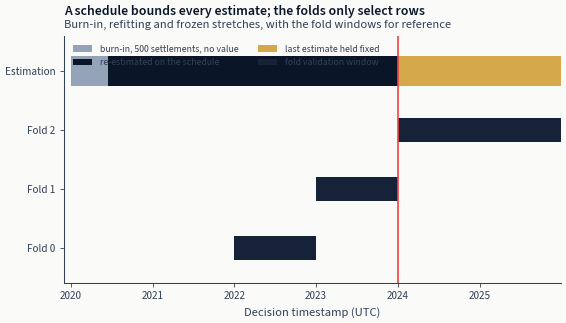

In [7]:
# The decision timeline, which is the grid both models step along. The exact burn-in end
# differs by a few settlements per series - a perpetual listed late pays its own - so what
# is drawn is the burn-in on the common grid rather than any one series' first valid bar.
_bars = labels["timestamp"].unique().sort()
_burnin_end = _bars[min(MIN_TRAIN_BARS, len(_bars) - 1)]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
_top = len(FOLDS_BY_DATE)
for start_ts, end_ts, color, name in (
    (_bars[0], _burnin_end, COLORS["recede"], f"burn-in, {MIN_TRAIN_BARS} settlements, no value"),
    (_burnin_end, holdout_start, COLORS["blue"], "re-estimated on the schedule"),
    (holdout_start, holdout_end, COLORS["amber"], "last estimate held fixed"),
):
    ax.barh(_top, end_ts - start_ts, left=start_ts, height=0.5, color=color, label=name)
for row, fold in enumerate(FOLDS_BY_DATE):
    ax.barh(
        row,
        fold["test_end"] - fold["test_start"],
        left=fold["test_start"],
        height=0.4,
        color=COLORS["blue_light"],
        label="fold validation window" if not row else "",
    )
ax.axvline(holdout_start, color=COLORS["negative"], linewidth=1.2)
ax.set_xlim(_bars[0] - pd.Timedelta(days=30), holdout_end)
ax.set_yticks(
    [*range(len(FOLDS_BY_DATE)), _top],
    [*[f"Fold {f['fold']}" for f in FOLDS_BY_DATE], "Estimation"],
)
ax.set_ylim(-0.6, _top + 0.6)
ax.set(xlabel="Decision timestamp (UTC)")
ax.legend(frameon=False, fontsize=7, loc="upper left", ncols=2)
add_message_title(
    ax,
    "A schedule bounds every estimate; the folds only select rows",
    subtitle="Burn-in, refitting and frozen stretches, with the fold windows for reference",
)
fig.tight_layout()
show_with_alt(
    fig,
    "A top bar spanning the funding history in three parts - a grey burn-in prefix carrying "
    "no value, a dark stretch over which parameters are re-estimated, and an amber stretch "
    "from the holdout boundary over which the last estimate is held fixed - above one bar per "
    "fold marking its validation window, none of which reaches the holdout.",
)

### The panel the models are fitted on

The universe is the perpetuals `config/setup.yaml` declares, and the panel is
**unbalanced**: a contract enters it on the day the exchange listed it, and there is
no backfill before that. That matters more here than it did in the last notebook, because a rolling
window can start returning values a few bars after a listing while a fitted model
cannot: it needs enough history for the parameters to be identified at all.

The frame the models read is the financial feature matrix joined to the label, which
is also the frame the evaluation at the end scores against. The raw 8-hour bars are
loaded separately for the volatility model, timestamped at the close of each bar
rather than its open, so a feature at a settlement uses only bars that had finished by
then.

One detail of the plumbing is worth fixing here rather than discovering later. Both
models run through pandas and hand their rows back stamped to the microsecond, while
every frame read off disk is stamped to the millisecond, and the two are joined on the
timestamp. So the panel's own resolution is read once, below, and each model's output
is cast to it as that output is built - rather than at whichever join first refuses.

In [8]:
financial = pl.read_parquet(FEATURES_DIR / "financial.parquet")
financial_feature_cols = [c for c in financial.columns if c not in ("timestamp", "symbol")]
# Hashed as read, before any filtering below, so the artifact this notebook writes
# records what it was actually built from.
FINANCIAL_DIGEST = value_digest(financial)

training_frame = financial.join(labels, on=["timestamp", "symbol"], how="inner").select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
)
if MAX_SYMBOLS > 0:
    # Most rows first, with the symbol name as an explicit tie-break: row counts tie
    # readily on this panel, and a tie broken by frame order is not stable across runs.
    keep = (
        training_frame.group_by("symbol")
        .len()
        .sort(["len", "symbol"], descending=[True, False])
        .head(MAX_SYMBOLS)["symbol"]
        .to_list()
    )
    training_frame = training_frame.filter(pl.col("symbol").is_in(keep))
symbols = sorted(training_frame["symbol"].unique().to_list())
financial = financial.filter(pl.col("symbol").is_in(symbols))
training_frame = training_frame.sort(["timestamp", "symbol"])

prices = (
    load_crypto_perps(frequency=f"{BAR_HOURS}h")
    .filter(pl.col("symbol").is_in(symbols))
    .with_columns((pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
n_symbols = len(symbols)
_missing = {"timestamp", "symbol", "close"} - set(prices.columns)
assert not _missing, f"the perpetual loader no longer returns {_missing}"
TIMESTAMP_DTYPE = financial.schema["timestamp"]

print(f"Feature matrix: {len(financial):,} rows x {len(financial_feature_cols)} features")
print(f"Joined to {PRIMARY_LABEL}: {len(training_frame):,} rows, {n_symbols} symbols")
print(f"Perpetual bars available: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

Feature matrix: 99,877 rows x 39 features
Joined to fwd_ret_8h: 99,851 rows, 19 symbols
Perpetual bars available: 2020-01-01 08:00:00+00:00 to 2026-01-01 00:00:00+00:00


The chart puts each symbol's available history against the two training windows. Read
it for where a bar starts: a perpetual whose listing falls inside or after a training
window has no history to fit in that fold, and the volatility model simply produces
nothing for it there. Those gaps are why the emitted artifact covers fewer symbols
than the universe configures, and the count is printed with each fold below rather
than left to be discovered downstream.

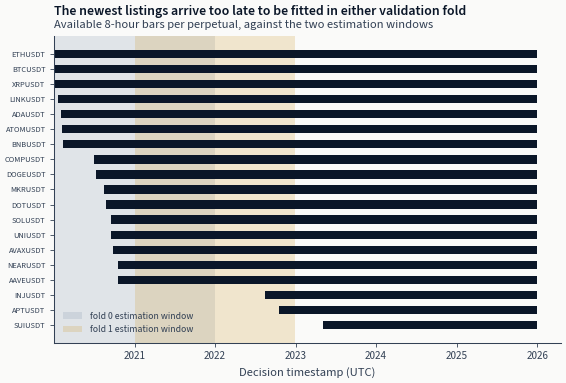

In [9]:
coverage = (
    prices.group_by("symbol")
    .agg(pl.col("timestamp").min().alias("first"), pl.col("timestamp").max().alias("last"))
    .sort("first", descending=True)
)
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
_VALIDATION_BY_DATE = [f for f in FOLDS_BY_DATE if f["fold"] in VALIDATION_FOLD_IDS]
for fold, color in zip(_VALIDATION_BY_DATE, (COLORS["recede"], COLORS["amber"]), strict=False):
    ax.axvspan(
        fold["train_start"],
        fold["train_end"],
        color=color,
        alpha=0.25,
        linewidth=0,
        label=f"fold {fold['fold']} estimation window",
    )
ax.barh(
    coverage["symbol"].to_list(),
    (coverage["last"] - coverage["first"]).to_list(),
    left=coverage["first"].to_list(),
    height=0.55,
    color=COLORS["blue"],
)
ax.set(xlabel="Decision timestamp (UTC)")
ax.tick_params(axis="y", labelsize=6)
ax.legend(frameon=False, fontsize=7, loc="lower left")
add_message_title(
    ax,
    "The newest listings arrive too late to be fitted in either validation fold",
    subtitle="Available 8-hour bars per perpetual, against the two estimation windows",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal bars showing each perpetual's span of available 8-hour bars, sorted by "
    "listing date, with the two shaded fold estimation windows behind them; the three "
    "most recent listings begin inside or after the later window.",
)

## C. The two fitted models

Both get the same treatment, and the shape is worth naming once because it is the whole
discipline of this stage.

A model-based feature has **two** channels through which a settlement's own future can
reach it. The first is the *conditioning set*: which observations the value at $t$ is
computed from. The second is the *parameters*: which observations $\theta$ was estimated
from. A causal feature needs both to stop at $t$, and it is easy to close the first and
leave the second open.

Until this notebook was rewritten it did exactly that. Each model was fitted once per
fold on that fold's whole training window, and then the recursion was run forward from
the **start** of that same window. The forward pass is genuinely one-directional, so the
conditioning channel was clean and the notebook's assertions - which checked it - passed.
But a settlement in the middle of a fold's training window was described by parameters
estimated from settlements up to two years after it. Validation settlements were clean on
both channels. So the model was fitted on one version of the column and scored on
another, and nothing raised, because a fold's rows are internally consistent and the
artifact recorded no estimation window.

What replaces it is a **refit schedule**, which is how `cme_futures` has always run its
ARIMA feature. Spend a burn-in of `MIN_TRAIN_BARS` settlements, fit, emit until the next
refit, re-estimate on everything up to that point, carry on to the end of the history.
The parameters behind any settlement's value come from settlements strictly before it,
whether that settlement is later used for training, for validation or for nothing.

Three consequences follow, and all three are improvements:

- **A fold no longer bounds an estimate**, so the artifact carries no `fold` column. One
  value per `(symbol, timestamp)`, the same value whichever fold selects the row. The
  file shrinks by its fold multiple, and a variant label reading it can no longer find
  a window the primary label's geometry never covered.
- **The burn-in is visible.** The first `MIN_TRAIN_BARS` settlements of a series carry no
  value, because on those settlements the feature genuinely did not exist. The old design
  produced numbers there by borrowing the future.
- **The property is testable.** Delete the last year of the history, re-run the walk, and
  every surviving value is unchanged. A fold-frozen fit fails that.

The holdout is the one place the walk stops re-estimating. A coefficient refitted on
holdout settlements is a parameter estimated on the holdout however causal the recursion
around it looks, so the last estimate made before the holdout opens is the one that
speaks for all of it - `freeze_after` in the driver below.

### C.1 Conditional volatility, per perpetual

**GARCH** models let today's variance depend on yesterday's variance and yesterday's
squared return, which is why a quiet week tends to be followed by a quiet day and a
violent one by another violent one. **GJR-GARCH** adds one term: a squared return
counts for more when the return was negative. That asymmetry is the reason to fit a
model here rather than take a rolling standard deviation, which weights a fall and an
equally large rise identically. In crypto perpetuals the difference is large, because
a fall liquidates leveraged longs and the forced selling moves price again.

Written out, the variance recursion is

$$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \gamma \varepsilon_{t-1}^2
  \mathbb{1}[\varepsilon_{t-1} < 0] + \beta h_{t-1}$$

where $\varepsilon_t$ is the return, $\alpha$ is how much an ordinary shock feeds
through, $\gamma$ the extra a downward shock feeds through, and $\beta$ how much of
yesterday's variance carries into today. Innovations are drawn from a Student-t
distribution rather than a normal one, because 8-hour crypto returns have far more
extreme observations than a normal distribution admits, and a normal fit compensates
by inflating $\omega$ for every bar.

In [10]:
def between(data, start: pd.Timestamp, end: pd.Timestamp):
    """The part of a time-indexed series or frame inside a closed interval."""
    return data.loc[(data.index >= start) & (data.index <= end)]


def fit_gjr_garch(returns: pd.Series) -> dict | None:
    """Fit GJR-GARCH(1,1) with Student-t innovations on one symbol's training returns."""
    if len(returns) < 100 or returns.std() < 1e-10:
        return None
    try:
        model = arch_model(returns * 100, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="StudentsT")
        result = model.fit(disp="off", show_warning=False)
    except Exception:
        return None
    # The seed and the clipping bounds are taken HERE, from the training residuals, and
    # travel with the coefficients. `arch` derives both from whatever sample it is handed,
    # and the sample the filter below is handed reaches the end of the block being emitted,
    # so deriving them there would read the block's own settlements. `variance_bounds` is
    # one pair per observation; the training window's widest pair is the fixed pair that
    # holds for the whole walk.
    residuals = np.asarray(result.resid, dtype=float)
    bounds = result.model.volatility.variance_bounds(residuals)
    return {
        "params": result.params,
        "gamma": result.params.get("gamma[1]", 0),
        "backcast": float(result.model.volatility.backcast(residuals)),
        "bounds": (float(np.min(bounds[:, 0])), float(np.max(bounds[:, 1]))),
        "coefficients": {
            name: float(result.params.get(f"{name}[1]", float("nan")))
            for name in ("alpha", "gamma", "beta")
        },
    }

Fitting and filtering are two calls, and the split is the point. `fit` searches for
the parameters that best explain the training returns; `fix` takes parameters it is
given and only runs the variance recursion with them. Handing `fix` the training and
validation returns together produces a conditional variance for every bar in the fold,
and the parameters in that recursion still came from the training window alone.

One step of arithmetic is added on top of what the library returns, and it is worth
following because the same off-by-one sits in any volatility feature built this way.
A library's conditional variance at bar $t$ is the variance **of** that bar: it is
built from the shock at $t-1$, so it is what a forecaster standing at $t-1$ would have
said about the bar now ending. A decision taken at $t$ has already seen the return
that just landed, so emitting that number at $t$ throws away the most recent
observation - the one a volatility model weights most heavily. Advancing the recursion
by one step, $h_{t+1} = \omega + (\alpha + \gamma \mathbb{1}[\varepsilon_t < 0])
\varepsilon_t^2 + \beta h_t$, gives the variance of the bar the decision at $t$ is
actually exposed to, and every term on the right is known at $t$.

In [11]:
def frozen_garch_path(fitted: dict, returns_prefix: np.ndarray) -> np.ndarray:
    """One-step-ahead volatility and the fitted asymmetry, for every bar of a prefix.

    ``returns_prefix`` is the symbol's return series from its first bar up to the end of the
    block being emitted, so the recursion starts where the series does and reaches exactly as
    far as the caller asked. The parameters are held fixed throughout; only the returns
    flowing through them change.
    """
    params = fitted["params"]
    omega, alpha, gamma, beta = (
        float(params[name]) for name in ("omega", "alpha[1]", "gamma[1]", "beta[1]")
    )
    shock = np.asarray(returns_prefix, dtype=float) * 100
    # `garch11_conditional_volatility` rather than `arch_model(...).fix(params)`. The two
    # run the same recursion, but `arch` re-derives the residuals, the backcast that seeds
    # h_0 and the variance bounds from the array it is given - and the array here reaches
    # the end of the block being emitted, so every one of those three reads settlements
    # after the value they shape. Measured on arch==8.0.0: extending the sample from 1,500
    # observations to 2,000 moves the 1,500 they share by up to 0.19%. Small, and a
    # dependence on the future in exactly the channel this walk exists to close. The seed
    # and the bounds come from `fit`, computed on training settlements alone.
    variance = (
        garch11_conditional_volatility(
            shock,
            mu=0.0,
            omega=omega,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            backcast=fitted["backcast"],
            bounds=fitted["bounds"],
        )
        ** 2
    )
    forecast = omega + (alpha + gamma * (shock < 0)) * shock**2 + beta * variance
    return np.column_stack(
        [np.sqrt(forecast) / 100, np.full(len(returns_prefix), float(fitted["gamma"]))]
    )

One symbol at a time, the extraction below slices the training returns, fits, runs the
frozen recursion, and returns both the feature rows and the interval the fit actually
consumed. That interval is what the assertion after the loop reads. Prose saying a fit
stayed inside its training window is worth nothing on its own; the check has to
recompute the window from the fit that ran.

In [12]:
def extract_symbol_garch(
    close: pd.Series, symbol: str
) -> tuple[pl.DataFrame, dict | None, list[dict]]:
    """Walk one symbol's whole return history, refitting on the schedule.

    Returns the emitted rows and a record of what the walk consumed. The record carries the
    LAST estimation window rather than a single one, because there is no single one any more:
    the schedule is the provenance, and the assertion after the loop checks it against
    ``refit_boundaries`` rather than against a fold.
    """
    returns = close.pct_change().dropna()
    if len(returns) <= MIN_TRAIN_BARS:
        return pl.DataFrame(schema=GARCH_SCHEMA), None, []
    freeze_after = int((returns.index < holdout_start).sum())
    fits: list[dict] = []

    def fit(train: np.ndarray) -> dict:
        fitted = fit_gjr_garch(pd.Series(train[:, 0]))
        if fitted is None:
            raise RuntimeError("GJR-GARCH did not fit")
        fits.append(
            {
                "symbol": symbol,
                "fit_end": returns.index[len(train) - 1],
                "n_fit": len(train),
                **fitted["coefficients"],
            }
        )
        return fitted

    values = walk_forward_feature(
        returns.to_numpy().reshape(-1, 1),
        timestamps=returns.index.to_numpy(),
        burnin=MIN_TRAIN_BARS,
        refit_every=GARCH_REFIT_EVERY,
        freeze_after=freeze_after,
        fit=fit,
        apply=lambda fitted, prefix: frozen_garch_path(fitted, prefix[:, 0]),
        n_features=2,
        on_fit_error="skip",
    )
    if not fits:
        return pl.DataFrame(schema=GARCH_SCHEMA), None, []
    frame = pl.DataFrame(
        {
            "timestamp": [
                pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts for ts in returns.index
            ],
            "symbol": [symbol] * len(returns),
            "garch_cond_vol": values[:, 0],
            "garch_asymmetry": values[:, 1],
        },
        schema=GARCH_SCHEMA,
        # `walk_forward_feature` marks the burn-in and any skipped block with NaN, which
        # polars keeps as a float value rather than a null. Without this the drop below
        # keeps every burn-in row, `first_valid` reports the start of the series instead
        # of the end of the burn-in, and the artifact's null counts read as zero on a
        # column that is unavailable for its first 500 settlements.
        nan_to_null=True,
    ).drop_nulls(subset=["garch_cond_vol"])
    provenance = {
        "symbol": symbol,
        "n_bars": len(returns),
        "n_refits": len(fits),
        "first_valid": frame["timestamp"].min(),
        "last_fit_ends": fits[-1]["fit_end"],
    }
    return frame, provenance, fits

The loop is orchestration only. Each symbol is independent and gets one walk over its
whole history; the count printed is the number of perpetuals whose history was long
enough to pay the burn-in at all.

In [13]:
close_by_symbol = {
    symbol: prices.filter(pl.col("symbol") == symbol)
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")["close"]
    for symbol in symbols
}

GARCH_SCHEMA = {
    "timestamp": TIMESTAMP_DTYPE,
    "symbol": pl.String,
    "garch_cond_vol": pl.Float64,
    "garch_asymmetry": pl.Float64,
}

garch_frames = []
garch_provenance = []
garch_coefficients: list[dict] = []
for symbol in symbols:
    frame, provenance, fits = extract_symbol_garch(close_by_symbol[symbol], symbol)
    if provenance is None:
        continue
    garch_frames.append(frame)
    garch_provenance.append(provenance)
    garch_coefficients.extend(fits)
garch_df = pl.concat(garch_frames) if garch_frames else pl.DataFrame(schema=GARCH_SCHEMA)
print(
    f"Volatility model: {len(garch_provenance)}/{n_symbols} perpetuals cleared the "
    f"{MIN_TRAIN_BARS}-settlement burn-in, "
    f"{sum(record['n_refits'] for record in garch_provenance):,} refits in total, "
    f"{garch_df.height:,} rows"
)

Volatility model: 19/19 perpetuals cleared the 500-settlement burn-in, 2,727 refits in total, 98,798 rows


The seal, recomputed from what each walk consumed rather than asserted in prose. Two
things have to hold, and they are the two channels named at the top of this section.

**No value precedes the parameters that describe it.** That is a property of the schedule
rather than of any one fit, so it is checked against the schedule: the first settlement
carrying a value has to be the one immediately after the burn-in, and the number of
refits has to be the number `refit_boundaries` says a series of that length gets.

**No parameter is estimated on the holdout.** The last estimation window closes before
the holdout opens, for every symbol.

In [14]:
garch_windows = pl.DataFrame(garch_provenance)
for record in garch_provenance:
    scheduled = refit_boundaries(record["n_bars"], MIN_TRAIN_BARS, GARCH_REFIT_EVERY)
    frozen = [pair for pair in scheduled if pair[0] <= record["n_bars"]]
    assert record["n_refits"] <= len(frozen), (
        f"{record['symbol']}: {record['n_refits']} refits against a schedule of {len(frozen)}"
    )
    assert record["last_fit_ends"] < holdout_start, (
        f"{record['symbol']}: an estimation window reaches {record['last_fit_ends']}, "
        f"at or past the holdout boundary {holdout_start}"
    )
print(
    f"{len(garch_windows)} volatility walks, "
    f"{garch_windows['n_refits'].sum():,} refits, none of them estimated on a settlement at or "
    f"after {holdout_start}. The earliest value any symbol carries is "
    f"{garch_windows['first_valid'].min()}, which is its own burn-in ending rather than a "
    "fold opening."
)

19 volatility walks, 2,727 refits, none of them estimated on a settlement at or after 2024-01-01 00:00:00+00:00. The earliest value any symbol carries is 2020-06-16 08:00:00+00:00, which is its own burn-in ending rather than a fold opening.


One derived column follows. The conditional volatility is a level, and a level is hard
to compare across perpetuals whose typical volatility differs by a factor of three, so
a z-score against each symbol's own trailing window says whether *this* symbol is
currently agitated relative to its own recent norm. It is computed within `symbol`,
over the one continuous conditional-volatility series each perpetual now has. Under the
previous design it had to be computed within `(fold, symbol)`, and the trailing window
restarted at every fold boundary; there are no boundaries left for it to restart at.
Its own warm-up - `VOL_ZSCORE_WINDOW` settlements after the model's burn-in - stays
null rather than being filled.

In [15]:
if garch_df.is_empty():
    raise RuntimeError("No volatility features produced")
garch_df = garch_df.sort(["symbol", "timestamp"]).with_columns(
    (
        (
            pl.col("garch_cond_vol")
            - pl.col("garch_cond_vol").rolling_mean(window_size=VOL_ZSCORE_WINDOW).over("symbol")
        )
        / pl.col("garch_cond_vol")
        .rolling_std(window_size=VOL_ZSCORE_WINDOW)
        .over("symbol")
        .clip(lower_bound=1e-10)
    )
    .clip(-VOL_ZSCORE_CLIP, VOL_ZSCORE_CLIP)
    .alias("garch_vol_zscore")
)
print(f"Volatility features: {len(garch_df):,} rows")

Volatility features: 98,798 rows


### C.2 Funding regimes, market-wide

The second model asks a question about the market rather than about a symbol. Funding
on a perpetual is the periodic payment between long and short holders that keeps the
contract near spot; when the whole universe is paying heavily in one direction, and
disagreeing about how much, the market is in a different state from a quiet week. A
**hidden Markov model** formalizes exactly that: it assumes an unobserved state that
switches between a small number of values, with a probability of switching estimated
from the data, and it assumes what you observe is drawn from a distribution that
depends on which state you are in.

The observation here is two-dimensional per settlement: the cross-sectional mean of
realized funding across the perpetuals quoting at that settlement, and its
cross-sectional standard deviation, both in basis points. Mean gives the direction the
market is paying, dispersion gives how much the contracts disagree. Two states is what
the notebook fits, and the state with the larger fitted dispersion is named the
stressed one - the naming has to be a property of the fit and not an accident of
labelling, because the algorithm returns the states in an arbitrary order and the same
regime can come back as state 0 in one fold and state 1 in the next.

In [16]:
agg_series = (
    financial.select("timestamp", "symbol", "funding_rate")
    .with_columns((pl.col("funding_rate") * 10_000).alias("funding_bps"))
    .group_by("timestamp")
    .agg(
        pl.col("funding_bps").mean().alias("xs_mean_funding_bps"),
        pl.col("funding_bps").std().alias("xs_std_funding_bps"),
        pl.col("funding_bps").count().alias("n_contracts"),
    )
    .filter(pl.col("n_contracts") >= 2)
    .select("timestamp", "xs_mean_funding_bps", "xs_std_funding_bps")
    .sort("timestamp")
    .drop_nulls()
)
print(f"Settlements the regime model reads: {len(agg_series):,}")

Settlements the regime model reads: 6,314


Two shared helpers do the work that must be identical everywhere it is used.
`filtered_state_probs` runs the forward recursion that gives $P(z_t \mid x_{1:t})$
rather than the smoothed posterior a library returns by default, and
`sort_states_by_variance` puts the states in dispersion order so state 0 means the same
thing at every refit. That second helper matters more under a schedule than it did under
a fold, not less: expectation-maximization labels its states arbitrarily, so without a
fixed ordering the feature would swap meaning several hundred times across the history
instead of twice. They live in `case_studies/utils/temporal.py` because a regime feature
is only comparable across estimates if every notebook orders its states the same way, and
because the forward recursion reaches a private method of the modelling library that
should be named in one place rather than several.

`fit_hmm_restarts` is the third, and it is the search. Expectation-maximization reaches
a local optimum, so this notebook has always fitted from ten starting points at every
refit and kept the one with the highest training likelihood. That loop used to live here;
it now lives in the shared module, because `etfs` and `fx_pairs` each wrote the same loop
for themselves and three copies of a selection rule is three places for it to drift.

What changed underneath it is where a restart begins. The fits are now initialized from a
k-means partition of the training window rather than by the modelling library's own
scheme, which is a starting point the data chose rather than one the seed did. The
restarts stay: measured on `etfs`' panel through this same estimator, ten of them give ten
distinct log-likelihoods, so the better start does not make the search redundant.

The fit is also held to a single compute thread, inside the shared helper rather than
here. The k-means partial sums are reduced across threads and floating-point addition is
not associative, so the starting means depend on how the work happened to be split and
expectation-maximization carries that into the transition matrix. Measured on that helper,
five thread counts gave five log-likelihoods and five transition matrices, and this
notebook's stage-04 artifact was one of three that hashed differently run to run because
of it. A seed fixes the draw and not the schedule; pinning the pool fixes both.

The convergence threshold is declared in `config/setup.yaml` rather than left to the
library. This notebook fits at `1e-4`, a hundred times tighter than hmmlearn's default,
and so does `fx_pairs`; `etfs` and `cme_futures` take the default. That difference was
measured on the `etfs` panel through this same estimator rather than argued about: across
twelve refit blocks the two thresholds move the emitted state probability by about
`1e-3` on average, by `0.229` at the single worst row, and **change none of 756 emitted
state assignments** at the one-half threshold. Zero flips is the decision result, not a
claim that the columns are identical - this probability is read as a continuous feature
as well as through a threshold, so the small differences are real even where no
classification moves. The declaration is there because two case studies chose the
tighter value deliberately, not because the looser one was shown to be wrong.

The extraction below fits on the fold's training settlements, then runs the forward
recursion over training and validation settlements together. Running it over the
joined stretch is not a shortcut: the filter needs the training observations to arrive
at the state distribution it holds when the validation window opens, and because the
recursion only ever looks backwards, a validation settlement's probability depends on
nothing after it.

In [17]:
def extract_hmm_walk(agg_pd: pd.DataFrame) -> tuple[pl.DataFrame, list[dict]]:
    """Walk the cross-sectional funding series, refitting the chain on the schedule.

    One diagnostics row per refit rather than per fold. The chain is re-estimated on
    everything up to each block boundary, so what the diagnostics table shows is how the
    regime description drifts across the history - which is the question a per-fold table
    could only answer at fold resolution.
    """
    observed = agg_pd[["xs_mean_funding_bps", "xs_std_funding_bps"]].dropna()
    freeze_after = int((observed.index < holdout_start).sum())
    diagnostics: list[dict] = []

    def fit(train: np.ndarray) -> tuple[GaussianHMM, np.ndarray]:
        fitted = fit_hmm_restarts(
            train,
            n_states=HMM_N_STATES,
            random_state=0,
            n_restarts=HMM_N_RESTARTS,
            tol=HMM_TOL,
        )
        model, log_likelihood = fitted.model, fitted.log_likelihood
        order = sort_states_by_variance(model)
        transition = model.transmat_[np.ix_(order, order)]
        # Expected run length of a state whose per-settlement chance of staying is p is
        # 1 / (1 - p) settlements.
        durations = 1.0 / (1.0 - np.diag(transition) + 1e-10)
        diagnostics.append(
            {
                "fit_end": observed.index[len(train) - 1],
                "n_fit": len(train),
                "log_likelihood": log_likelihood,
                "calm_duration_bars": float(durations[0]),
                "stress_duration_bars": float(durations[1]),
            }
        )
        return model, order

    values = walk_forward_feature(
        observed.values,
        timestamps=observed.index.to_numpy(),
        burnin=MIN_TRAIN_BARS,
        refit_every=HMM_REFIT_EVERY,
        freeze_after=freeze_after,
        fit=fit,
        apply=lambda fitted, prefix: filtered_state_probs(fitted[0], prefix)[:, fitted[1]],
        n_features=HMM_N_STATES,
    )
    frame = pl.DataFrame(
        {
            "timestamp": [
                pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts for ts in observed.index
            ],
            "hmm_regime_prob_calm": values[:, 0],
            "hmm_regime_prob_stress": values[:, 1],
        },
        schema={
            "timestamp": TIMESTAMP_DTYPE,
            "hmm_regime_prob_calm": pl.Float64,
            "hmm_regime_prob_stress": pl.Float64,
        },
        # Same reason as the volatility frame: the burn-in arrives as NaN, and NaN is a
        # float in polars, not a null.
        nan_to_null=True,
    ).drop_nulls()
    return frame, diagnostics

In [18]:
agg_pd = agg_series.to_pandas().set_index("timestamp")
hmm_df, hmm_diagnostics = extract_hmm_walk(agg_pd)
if hmm_df.is_empty():
    raise RuntimeError("the regime model produced no settlement, so the feature does not exist")
print(
    f"Regime probabilities: {hmm_df.height:,} settlements from "
    f"{hmm_df['timestamp'].min()}, {len(hmm_diagnostics)} refits"
)

Regime probabilities: 5,814 settlements from 2020-07-16 00:00:00+00:00, 58 refits


The same seal as the volatility model, recomputed from the settlements each regime fit
consumed. There is one series here rather than nineteen, so the schedule is checked
exactly rather than as a bound, and the last estimation window is displayed beside the
holdout boundary it has to precede.

In [19]:
_hmm_sealed = pl.DataFrame(hmm_diagnostics)
_observed_bars = agg_pd[["xs_mean_funding_bps", "xs_std_funding_bps"]].dropna()
_scheduled = refit_boundaries(len(_observed_bars), MIN_TRAIN_BARS, HMM_REFIT_EVERY)
_estimated = [
    pair for pair in _scheduled if pair[0] <= (_observed_bars.index < holdout_start).sum()
]
assert len(_hmm_sealed) == len(_estimated), (
    f"{len(_hmm_sealed)} regime fits against a schedule of {len(_estimated)}"
)
assert (_hmm_sealed["n_fit"] == [pair[0] for pair in _estimated]).all(), (
    "a regime fit read a different number of settlements than its block boundary allows"
)
assert _hmm_sealed["fit_end"].max() < holdout_start, (
    "a regime fit read a settlement at or after the holdout boundary"
)
print(
    f"{len(_hmm_sealed)} regime fits; the last reads through {_hmm_sealed['fit_end'].max()}, "
    f"and the holdout opens {holdout_start}. Every settlement from that point on carries "
    "that estimate."
)
display(_hmm_sealed.tail(5))

58 regime fits; the last reads through 2023-12-21 16:00:00+00:00, and the holdout opens 2024-01-01 00:00:00+00:00. Every settlement from that point on carries that estimate.


fit_end,n_fit,log_likelihood,calm_duration_bars,stress_duration_bars
"datetime[μs, UTC]",i64,f64,f64,f64
2023-09-28 16:00:00 UTC,3839,-13093.020445,16.621928,10.04568
2023-10-19 16:00:00 UTC,3902,-13156.630639,17.019364,10.246976
2023-11-09 16:00:00 UTC,3965,-13277.807091,17.220336,10.162228
2023-11-30 16:00:00 UTC,4028,-13428.491485,17.483839,10.069211
2023-12-21 16:00:00 UTC,4091,-13660.275977,17.312905,9.790781


The figure below is what a filtered regime probability looks like, drawn against the
series it was inferred from so the two can be read together. The top panel is the
cross-sectional funding the model observes; the bottom is the probability it assigns
to the stressed state, on validation settlements only, so every value shown comes from
a model fitted on earlier bars. Read the bottom panel for how the probability behaves,
not for where it happens to be high: it moves between its bounds within a day rather
than drifting, which is the signature of a filter that revises hard on each new
observation and is what makes the feature a state indicator rather than a trend.

In [20]:
# The series is now continuous, so it is drawn continuously and the validation windows are
# marked on it rather than being what the line is made of.
regime_view = (
    hmm_df.join(agg_series, on="timestamp", how="inner")
    .filter(pl.col("timestamp") < holdout_start)
    .sort("timestamp")
)

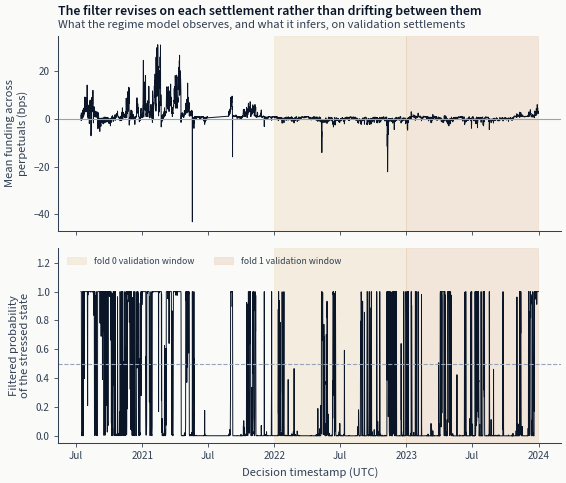

In [21]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)
_stamps = regime_view["timestamp"].to_list()
axes[0].plot(
    _stamps, regime_view["xs_mean_funding_bps"].to_list(), color=COLORS["blue"], linewidth=0.7
)
axes[1].plot(
    _stamps, regime_view["hmm_regime_prob_stress"].to_list(), color=COLORS["blue"], linewidth=0.7
)
for color, fold in zip((COLORS["amber"], COLORS["copper"]), _VALIDATION_BY_DATE, strict=False):
    for axis in axes:
        axis.axvspan(
            fold["test_start"],
            fold["test_end"],
            color=color,
            alpha=0.15,
            label=f"fold {fold['fold']} validation window" if axis is axes[1] else None,
        )
axes[0].axhline(0, color=COLORS["recede"], linewidth=0.8)
axes[0].set_ylabel("Mean funding across\nperpetuals (bps)")
axes[1].axhline(0.5, color=COLORS["recede"], linewidth=0.8, linestyle="--")
axes[1].set_ylim(-0.05, 1.3)
axes[1].set(xlabel="Decision timestamp (UTC)", ylabel="Filtered probability\nof the stressed state")
axes[1].legend(loc="upper left", ncols=2, frameon=False, fontsize=7)
_locator = mdates.AutoDateLocator(maxticks=7)
axes[1].xaxis.set_major_locator(_locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(_locator))
add_message_title(
    axes[0],
    "The filter revises on each settlement rather than drifting between them",
    subtitle="What the regime model observes, and what it infers, on validation settlements",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Two stacked time-series panels over the two validation windows: the upper shows "
    "mean cross-sectional funding in basis points oscillating around zero, the lower "
    "shows the filtered stressed-state probability switching sharply between zero and "
    "one rather than moving smoothly.",
)

## D. Do the fitted parameters move as the window rolls?

Both models are re-estimated on a schedule that runs the length of the history, and that
choice is only worth its cost if the estimates actually move. Parameters that come back
identical from one refit to the next would say the schedule bought nothing and a single
early fit would have done. Parameters that drift say something more useful and more
uncomfortable: the feature means a slightly different thing at different points in the
sample, and a model pooling the whole series is pooling quantities calibrated differently.

This is the question the old per-fold design could only answer at fold resolution - three
estimates, one per fold, with no way to tell a genuine drift from the difference between
two overlapping ten-year windows. The schedule gives one estimate every
`GARCH_REFIT_EVERY` settlements, so the coefficient path is a series and can be read as
one.

The two models get a chart each, because their units do not compare: a recursion
coefficient is dimensionless and a regime duration is counted in settlements.

What is plotted for the volatility model is **persistence**, $\alpha + \beta +
\gamma/2$ - the fraction of a variance shock still present one settlement later, with
the asymmetry term at half weight because it is active on the half of settlements that
fall. Persistence is the quantity to read rather than any single coefficient, because
the coefficients trade off against each other: one can rise while another falls and
leave the decay rate unchanged, so a claim of stability read off $\alpha$ alone can be
wrong in either direction. The model is fitted per perpetual, so the median across
symbols is drawn with the interquartile range behind it. For the regime model the
quantity is the expected run length of each state, in settlements.

Each perpetual is refit on its own settlements, because its walk starts from its own
listing, so the refit dates do not line up across symbols. Taking the cross-section at
each date a fit happened would therefore compare a changing subset of perpetuals - and a
date where one symbol refit would show a median of one model and an interquartile range
of zero, which reads as agreement rather than as a group of one. Each symbol's most
recent estimate is carried forward onto a common timeline instead, so every point is the
cross-section of every perpetual that had a fitted model by then.

In [22]:
GARCH_COEFFICIENTS = ["alpha", "gamma", "beta"]

coefficient_frame = pl.DataFrame(garch_coefficients).with_columns(
    (pl.col("alpha") + pl.col("beta") + pl.col("gamma") / 2).alias("persistence")
)
# The timeline is every date any perpetual refit on; the as-of join carries each symbol's
# latest estimate forward to each of them, and a symbol with no fit yet stays absent rather
# than being filled.
_coefficient_timeline = coefficient_frame.select(pl.col("fit_end").unique().sort())
_coefficient_aligned = pl.concat(
    [
        _coefficient_timeline.join_asof(
            part.sort("fit_end"), on="fit_end", strategy="backward"
        ).drop_nulls(subset=["persistence"])
        for (_symbol,), part in coefficient_frame.group_by(["symbol"], maintain_order=True)
    ]
)
coefficient_stability = (
    _coefficient_aligned.group_by("fit_end")
    .agg(
        [
            expression
            for name in [*GARCH_COEFFICIENTS, "persistence"]
            for expression in (
                pl.col(name).median().alias(f"{name}_median"),
                pl.col(name).quantile(0.25).alias(f"{name}_q25"),
                pl.col(name).quantile(0.75).alias(f"{name}_q75"),
            )
        ]
        + [pl.len().alias("n_symbols")]
    )
    .sort("fit_end")
)
duration_stability = pl.DataFrame(hmm_diagnostics).sort("fit_end")
display(
    coefficient_stability.select(
        "fit_end", "n_symbols", *[f"{n}_median" for n in [*GARCH_COEFFICIENTS, "persistence"]]
    ).tail(8)
)
display(duration_stability.select("fit_end", "calm_duration_bars", "stress_duration_bars").tail(8))

fit_end,n_symbols,alpha_median,gamma_median,beta_median,persistence_median
"datetime[μs, UTC]",u32,f64,f64,f64,f64
2023-12-25 08:00:00 UTC,19,0.087426,0.00524,0.920653,1.0
2023-12-26 00:00:00 UTC,19,0.087602,0.00524,0.920653,1.0
2023-12-26 16:00:00 UTC,19,0.087602,0.00524,0.917664,1.0
2023-12-28 00:00:00 UTC,19,0.087602,0.00524,0.917664,1.0
2023-12-28 08:00:00 UTC,19,0.087602,0.00524,0.917664,1.0
2023-12-29 00:00:00 UTC,19,0.087602,0.00524,0.917664,1.0
2023-12-29 08:00:00 UTC,19,0.087602,0.004183,0.917664,1.0
2023-12-31 08:00:00 UTC,19,0.087602,0.004183,0.917664,1.0


fit_end,calm_duration_bars,stress_duration_bars
"datetime[μs, UTC]",f64,f64
2023-07-27 16:00:00 UTC,15.988552,9.932141
2023-08-17 16:00:00 UTC,16.104302,9.951875
2023-09-07 16:00:00 UTC,16.420166,10.01066
2023-09-28 16:00:00 UTC,16.621928,10.04568
2023-10-19 16:00:00 UTC,17.019364,10.246976
2023-11-09 16:00:00 UTC,17.220336,10.162228
2023-11-30 16:00:00 UTC,17.483839,10.069211
2023-12-21 16:00:00 UTC,17.312905,9.790781


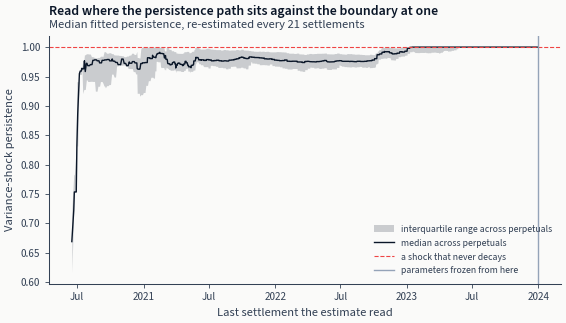

In [23]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
_fit_ends = coefficient_stability["fit_end"].to_list()
ax.fill_between(
    _fit_ends,
    coefficient_stability["persistence_q25"].to_list(),
    coefficient_stability["persistence_q75"].to_list(),
    color=COLORS["blue"],
    alpha=0.2,
    linewidth=0,
    label="interquartile range across perpetuals",
)
ax.plot(
    _fit_ends,
    coefficient_stability["persistence_median"].to_list(),
    color=COLORS["blue"],
    linewidth=1.0,
    label="median across perpetuals",
)
ax.axhline(1.0, color=COLORS["negative"], lw=0.8, ls="--", label="a shock that never decays")
ax.axvline(holdout_start, color=COLORS["recede"], lw=1.0, label="parameters frozen from here")
ax.set_ylabel("Variance-shock persistence")
ax.set_xlabel("Last settlement the estimate read")
ax.legend(frameon=False, fontsize=7, loc="lower right")
_locator = mdates.AutoDateLocator(maxticks=7)
ax.xaxis.set_major_locator(_locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_locator))
add_message_title(
    ax,
    "Read where the persistence path sits against the boundary at one",
    subtitle=f"Median fitted persistence, re-estimated every {GARCH_REFIT_EVERY} settlements",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Median variance-shock persistence across perpetuals against the last settlement each "
    "estimate read, with an interquartile band, a dashed line at one marking a shock that "
    "never decays, and a vertical line where the parameters are frozen for the holdout.",
)

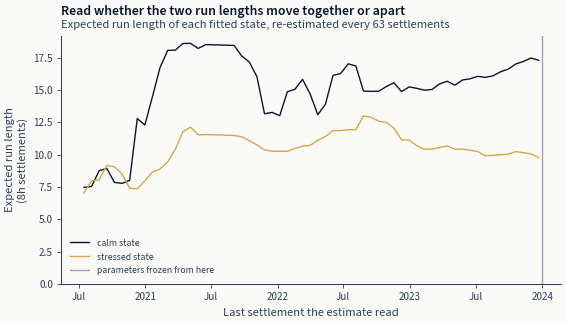

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for column, name, color in (
    ("calm_duration_bars", "calm state", COLORS["blue"]),
    ("stress_duration_bars", "stressed state", COLORS["amber"]),
):
    ax.plot(
        duration_stability["fit_end"].to_list(),
        duration_stability[column].to_list(),
        color=color,
        linewidth=1.0,
        label=name,
    )
ax.axvline(holdout_start, color=COLORS["recede"], lw=1.0, label="parameters frozen from here")
ax.set_ylim(bottom=0)
ax.set_ylabel(f"Expected run length\n({BAR_HOURS}h settlements)")
ax.set_xlabel("Last settlement the estimate read")
ax.legend(frameon=False, fontsize=7)
_locator = mdates.AutoDateLocator(maxticks=7)
ax.xaxis.set_major_locator(_locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_locator))
add_message_title(
    ax,
    "Read whether the two run lengths move together or apart",
    subtitle=f"Expected run length of each fitted state, re-estimated every {HMM_REFIT_EVERY} "
    "settlements",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Expected run length of the calm and the stressed regime against the last settlement "
    "each estimate read, with a vertical line where the parameters are frozen for the "
    "holdout.",
)

**What to read off the two charts.** Three things, in order.

Whether the **median persistence path touches the dashed line at one**. A fit at that
boundary is censored there: it cannot distinguish "extremely persistent" from
"integrated", and while it sits on the line the individual coefficients are not
separately identified. This is why persistence is plotted rather than $\alpha$ or
$\beta$ alone - either can move a long way while the decay rate does not.

Whether the **interquartile band is wide or narrow**. A wide band means the perpetuals
disagree about how persistent variance is, which is what makes a per-symbol fit worth
its cost. A band that collapses would say a single pooled fit would serve.

Whether the **paths move at all**. If they are flat, the refit schedule bought nothing
and its only remaining justification is that a schedule is what makes the feature causal
in the first place - which is reason enough, but worth knowing. If they drift, the
feature is calibrated differently at different points in the sample, and a model pooling
the history should know that.

The vertical line on both charts is where re-estimation stops. Every settlement to the
right of it carries the last estimate made to its left, which is what keeps the holdout
out of the parameters while still giving it values.

## E. Combine and emit

The two models produce differently shaped output. The volatility model gives one row per
perpetual and settlement; the regime model gives one row per settlement, because it
describes the market rather than any single contract. Combining them means broadcasting
the market-level probabilities across the symbols quoting at each settlement.

**The key is `(timestamp, symbol)` and nothing else.** Under the previous design it was
`(timestamp, symbol, fold)`, because the same settlement carried a different value in
every fold - which is what a fold-frozen fit produces and what made the file several
times larger than the panel it describes. A settlement now has one value, computed once,
and whichever fold a model notebook later assigns that row to does not change it.

In [25]:
hmm_broadcast = hmm_df.join(pl.DataFrame({"symbol": symbols}), how="cross").select(
    ["timestamp", "symbol", "hmm_regime_prob_calm", "hmm_regime_prob_stress"]
)
temporal = (
    garch_df.select(
        ["timestamp", "symbol", "garch_cond_vol", "garch_vol_zscore", "garch_asymmetry"]
    )
    .join(hmm_broadcast, on=["timestamp", "symbol"], how="left")
    .sort(["symbol", "timestamp"])
    .drop_nulls(subset=["garch_cond_vol", "garch_asymmetry"])
    # The walk runs over each perpetual's whole return history, which can extend past the
    # end of the holdout window; the fold-keyed design was bounded by the fold windows and
    # never had to say so. A settlement past `holdout_end` belongs to no training,
    # validation or holdout window, so no stage reads it. Emitting it anyway would put rows
    # in the artifact that describe a period the case study does not evaluate, and would
    # make the coverage guard below unable to distinguish that from an estimate leaking
    # into a period it should not describe.
    .filter(pl.col("timestamp") <= holdout_end)
)
temporal_feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol")]

Three kinds of missing value survive into the artifact on purpose, and it is worth being
precise about which, because the notebooks downstream impute and need to know what they
are imputing.

**The burn-in.** No perpetual carries a volatility value over its first
`MIN_TRAIN_BARS` settlements, and no settlement carries a regime probability over the
first `MIN_TRAIN_BARS` of the funding series. On those settlements the feature genuinely
did not exist - there was not yet enough history to estimate it from. The previous design
produced numbers there, by fitting on the fold's whole training window and running the
recursion backwards over it, and that is the defect this rewrite removes. A null here is
the honest answer and a number would not be.

**The z-score warm-up.** `garch_vol_zscore` is null for a further `VOL_ZSCORE_WINDOW`
settlements after its symbol's volatility series begins, because a trailing mean and
standard deviation need that much history of their own.

**A settlement the funding panel does not carry.** The regime probabilities are null
wherever the perpetual bar grid has a settlement the funding panel does not, since the
regime model is fitted on funding and cannot speak about a settlement it never saw. A
probability that was never inferred is left absent rather than filled with a number that
would read as a confident answer.

In [26]:
display(
    pl.DataFrame(
        {
            "feature": temporal_feature_cols,
            "mean": [temporal[c].mean() for c in temporal_feature_cols],
            "standard_deviation": [temporal[c].std() for c in temporal_feature_cols],
            "null_fraction": [
                temporal[c].null_count() / len(temporal) for c in temporal_feature_cols
            ],
        }
    )
)
print(f"Rows: {len(temporal):,}   symbols: {temporal['symbol'].n_unique()}")
print(f"Period: {temporal['timestamp'].min()} to {temporal['timestamp'].max()}")

feature,mean,standard_deviation,null_fraction
str,f64,f64,f64
"""garch_cond_vol""",0.029794,0.014407,0.0
"""garch_vol_zscore""",-0.041518,1.24181,0.017126
"""garch_asymmetry""",0.012538,0.034382,0.0
"""hmm_regime_prob_calm""",0.827723,0.357994,0.030656
"""hmm_regime_prob_stress""",0.172277,0.357994,0.030656


Rows: 98,741   symbols: 19
Period: 2020-06-16 08:00:00+00:00 to 2025-12-31 00:00:00+00:00


Three guards run before the write, because a feature artifact is read by every model
notebook and a defect in it is cheapest to catch here. The schema is frozen against
the five names this stage contracts to produce, so a renamed or extra column fails
rather than propagating. No `(timestamp, symbol)` key may appear twice, since a
duplicate would silently multiply rows in every join downstream. And the holdout window
has to be covered, with values whose parameters stopped at its boundary.

Beside the parquet goes a **digest sidecar**, a small JSON file recording what was
written: a hash taken over the values themselves, the row count, the key columns, and
the same hash taken over each artifact these values were built from. It is computed
over content rather than file bytes, so rewriting the file in a different row order
leaves it alone while changing a single feature value moves it. The input digests are
taken over the frames this notebook read rather than copied from the sidecars beside
them, so what the chain records is what was actually loaded. That is the check the
experiment registry cannot make: the registry records the *name* of a feature set, so
corrected features change every number downstream without changing anything the
registry stores.

In [27]:
EXPECTED_TEMPORAL = {
    "garch_cond_vol",
    "garch_vol_zscore",
    "garch_asymmetry",
    "hmm_regime_prob_calm",
    "hmm_regime_prob_stress",
}
assert set(temporal_feature_cols) == EXPECTED_TEMPORAL, "the emitted schema is not the contract"
assert temporal.select("timestamp", "symbol").is_duplicated().sum() == 0

# Coverage of the holdout, checked in both directions. "No row reaches the holdout" would only
# catch an estimate leaking into a period it should not describe. It cannot catch the opposite
# failure, which is a holdout window containing nothing at all, and that is the failure this
# notebook actually had: it passed for months while the artifact carried no holdout-dated row
# of any kind. Both directions still matter with the fold column gone - what changed is that
# the containment is now a property of where PARAMETERS came from, which the seals in section C
# assert, rather than of which rows carry which fold id.
assert temporal["timestamp"].max() <= holdout_end, (
    "a row was emitted past the end of the holdout window"
)
_inside = temporal.filter(pl.col("timestamp") >= holdout_start)
assert _inside.height > 0, (
    "no holdout-dated row was written, and the holdout is what the final notebook scores on"
)
for column in sorted(EXPECTED_TEMPORAL):
    non_null = _inside.get_column(column).drop_nulls().len()
    assert non_null > 0, (
        f"{column} is null on every holdout-dated row, so the row is present and the feature "
        "is not - a fit that produced nothing reads exactly like one that was never asked"
    )
print(
    f"Holdout window: {_inside.height:,} rows, {_inside['symbol'].n_unique()} symbols, "
    f"{_inside['timestamp'].min()} to {_inside['timestamp'].max()}. Every value in it was "
    "produced by parameters estimated before the window opened."
)

record = write_model_based(
    temporal,
    FEATURES_DIR / "model_based.parquet",
    keys=["symbol", "timestamp"],
    feature_columns=sorted(EXPECTED_TEMPORAL),
    time_column="timestamp",
    # No fold column. Every parameter behind a value is bounded by the refit schedule
    # declared above, not by a fold, so a symbol-settlement carries one value whichever
    # fold reads it and the identity is the keys alone.
    fold_column=None,
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={
        "financial": FINANCIAL_DIGEST,
        "load_crypto_perps": value_digest(prices),
    },
    # The estimation schedule, stated rather than left to be inferred. This replaces the
    # `fold_geometry` block the artifact used to carry, and it answers the same question:
    # what bounded the parameters behind a value. A reader that wants to know why a row is
    # null needs the burn-in; a reader that wants to know whether a value could have been
    # computed on the day it is dated needs the refit cadence and the freeze point.
    metadata={
        "estimation_schedule": {
            "burnin_bars": MIN_TRAIN_BARS,
            "garch_refit_every_bars": GARCH_REFIT_EVERY,
            "hmm_refit_every_bars": HMM_REFIT_EVERY,
            "expanding_window": True,
            "parameters_frozen_from": str(holdout_start),
            "garch_refits": int(sum(r["n_refits"] for r in garch_provenance)),
            "hmm_refits": len(hmm_diagnostics),
        }
    },
)
print(f"Wrote features/model_based.parquet, {record['n_rows']:,} rows, digest {record['digest']}")

Holdout window: 41,629 rows, 19 symbols, 2024-01-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00. Every value in it was produced by parameters estimated before the window opened.
Wrote features/model_based.parquet, 98,741 rows, digest fb4294aae2cd8ecd


Reloading through the shared modeling path is what makes the next cell a check rather
than a claim. `load_modeling_dataset` is the route every model notebook takes; it
re-derives the fold boundaries from the label file, and until this rewrite it also
refused an artifact whose folds did not cover them. There are no folds in the artifact
any more, so what it does instead is join these five columns onto the panel by
`(timestamp, symbol)` - the path `nasdaq100_microstructure` already takes. Running it
here, against the file just written, is the earliest point at which a mismatch can be
caught.

In [28]:
assembled = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, symbols=symbols)
assert set(assembled.temporal_feature_names) == EXPECTED_TEMPORAL, (
    f"the loader reports {sorted(assembled.temporal_feature_names)}, not the five this "
    "stage contracts to produce"
)
# The artifact carries no fold column, so the loader takes its single-feature-set path and
# joins these columns straight onto the panel. `temporal_by_fold` is therefore absent, and
# asserting that is the check: a non-None value here would mean a fold column survived the
# rewrite and every consumer would be back to substituting values per fold.
assert assembled.temporal_by_fold is None, (
    "the loader found a fold-keyed temporal artifact, so the fold column was not dropped"
)
assert assembled.label_col == label_col, (
    f"the loader assembled label {assembled.label_col}, not {label_col}"
)
assert len(assembled.feature_names) == len(financial_feature_cols) + len(EXPECTED_TEMPORAL), (
    f"the loader assembled {len(assembled.feature_names)} features, not the "
    f"{len(financial_feature_cols)} price and funding features plus "
    f"{len(EXPECTED_TEMPORAL)} model-based ones"
)

reassembled_frame = assembled.dataset.select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
).sort(["timestamp", "symbol"])
assert reassembled_frame.equals(training_frame), (
    "the loader assembles a different feature frame from the one this notebook read"
)
print(
    f"Training assembly: {len(financial_feature_cols)} price and funding features plus "
    f"{len(EXPECTED_TEMPORAL)} model-based features, joined on (timestamp, symbol)"
)

Training assembly: 39 price and funding features plus 5 model-based features, joined on (timestamp, symbol)


## F. Incremental evaluation

One question, on validation settlements only: how strongly does each of these five
features rank the cross-section on its own, and where does that put it against the
price and funding features the last notebook already produced?

Be precise about what that can and cannot settle, because the loose version of it is
the commonest way to oversell a feature. A side-by-side of stand-alone correlations
says where each feature sits on its own. It does **not** say whether a feature adds
anything on top of the others: two features with the same stand-alone correlation can
carry the same information twice or carry different information entirely, and nothing
in a marginal comparison tells them apart. Separating them takes a model fitted with
the feature and again without it, and a comparison of the two - which is a different
measurement from anything drawn here, and one this pipeline does not currently make.
**Nothing is selected here**; the feature screen that decides what goes forward is
[`05_evaluation`](05_evaluation.ipynb).

The measure is the **information coefficient**: at each settlement, the rank
correlation across the perpetuals quoting then, between what the feature says and what
the next 8 hours actually returned. That gives one number per settlement, and the
series of them is what gets averaged. Averaging a series of within-settlement
correlations keeps every settlement equally weighted however many perpetuals quoted
at it, and keeps the question to one about ranking inside a settlement rather than
about levels across time.

In [29]:
# A settlement now carries one value rather than one per fold, so a validation row is
# selected by its timestamp alone. The windows do not overlap - `generate_cv_splits` lays
# them end to end - so concatenating them cannot duplicate a row, and the assertion below
# checks that rather than assuming it.
validation_temporal = pl.concat(
    [
        temporal.filter(
            pl.col("timestamp").is_between(fold["test_start"], fold["test_end"], closed="both")
        )
        for fold in VALIDATION_FOLDS
    ]
)
assert validation_temporal.select("timestamp", "symbol").is_duplicated().sum() == 0, (
    "two validation windows claim the same settlement, so a row would be scored twice"
)
eval_df = validation_temporal.join(training_frame, on=["timestamp", "symbol"], how="inner").sort(
    ["timestamp", "symbol"]
)
assert eval_df["timestamp"].max() < holdout_start, "the diagnostic reads a holdout settlement"
print(f"Validation rows scored: {len(eval_df):,}, label {label_col}")

Validation rows scored: 34,140, label fwd_ret_8h


Two details of how the series is built decide whether the significance test means
anything.

The first is order. `compute_ic_hac_stats` applies a Newey-West correction, which
widens a standard error to account for a series being correlated with its own recent
past - and it reads row order as time order without sorting. A Polars `group_by`
returns groups in whatever order the frame produced them, not in sorted key order, so
a series built by grouping and passed straight in carries a correction computed over
an arbitrary permutation of the timeline. The series here comes from
`cross_sectional_ic_series`, which sorts on the decision timestamp itself, so the
ordering is a property of the library call rather than of a sort that some later edit
has to preserve.

The second is what an undefined correlation looks like. A market-level regime
probability takes the same value for every perpetual at a settlement, so the ranks
within that settlement have no spread and the correlation has a zero denominator. That
arrives as a `NaN` rather than as a missing value, which is why the filter tests for a
finite number: the two regime columns would otherwise travel into the significance
test and come back out as a row of `NaN` statistics.

In [30]:
def ic_stats(frame: pl.DataFrame, feature: str) -> dict | None:
    """HAC-corrected statistics for one feature's per-settlement IC series."""
    series = cross_sectional_ic_series(
        frame,
        frame,
        pred_col=feature,
        ret_col=label_col,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    ).filter(pl.col("ic").is_finite())
    if len(series) < MIN_DECISION_TIMES:
        return None
    return compute_ic_hac_stats(series, ic_col="ic", label_horizon=LABEL_HORIZON_BARS)


temporal_ic = {f: s for f in temporal_feature_cols if (s := ic_stats(eval_df, f)) is not None}
financial_ic = {f: s for f in financial_feature_cols if (s := ic_stats(eval_df, f)) is not None}
print(
    f"Ranked: {len(temporal_ic)} of {len(temporal_feature_cols)} model-based features and "
    f"{len(financial_ic)} of {len(financial_feature_cols)} price and funding features"
)
for direction, pick in (("Most negative", min), ("Most positive", max)):
    if financial_ic:
        name, _ = pick(financial_ic.items(), key=lambda item: item[1]["mean_ic"])
        print(f"{direction} mean IC among the price and funding features: {name}")

Ranked: 3 of 5 model-based features and 37 of 39 price and funding features
Most negative mean IC among the price and funding features: price_vol_7d
Most positive mean IC among the price and funding features: premium_accel_short


Screening the whole set at once gives as many chances to find a significant feature
where there is nothing, so the p-values are corrected for it. The
**Benjamini-Hochberg** procedure controls the expected share of false claims among
whatever it declares significant,
which is the right target when the point is to decide which features to carry forward
rather than to defend a single hypothesis. It is applied across the model-based
features alone, because those are the ones this notebook is screening; the price and
funding features enter the chart as a reference and are tested in `05_evaluation`
along with everything else.

In [31]:
temporal_summary = pl.DataFrame(
    {
        "feature": list(temporal_ic),
        "mean_ic": [temporal_ic[n]["mean_ic"] for n in temporal_ic],
        "hac_se": [temporal_ic[n]["hac_se"] for n in temporal_ic],
        "hac_tstat": [temporal_ic[n]["t_stat"] for n in temporal_ic],
        "p_value": [temporal_ic[n]["p_value"] for n in temporal_ic],
    }
).sort("mean_ic", descending=True)
_fdr = benjamini_hochberg_fdr(temporal_summary["p_value"].to_list(), alpha=0.05)
temporal_summary = temporal_summary.with_columns(pl.Series("fdr_significant", list(_fdr)))
display(temporal_summary)

feature,mean_ic,hac_se,hac_tstat,p_value,fdr_significant
str,f64,f64,f64,f64,bool
"""garch_asymmetry""",0.01834,0.00528,3.473302,0.000525,true
"""garch_vol_zscore""",-0.004249,0.005884,-0.722242,0.470231,false
"""garch_cond_vol""",-0.038893,0.007433,-5.232094,1.8531e-7,true


Both halves of the comparison go on one axis, because the whole question is where one
sits relative to the other. Each model-based feature gets a bar at its mean information
coefficient, with whiskers at the interval its HAC-corrected standard error implies,
filled where the feature clears the multiplicity correction and hollow where it does
not - so a bar that is long but uncertain cannot be mistaken for a finding.

The row of dots above them is what makes "incremental" visible rather than asserted:
one dot per price and funding feature from the previous notebook, its information
coefficient computed on these same validation settlements. It shows the range the
existing features already occupy, so a model-based feature can be read as inside that
range or outside it instead of in isolation.

Two of those features are missing from the row, for exactly the reason the regime
probabilities are missing from the bars: `funding_session` is a property of the
settlement and `xs_funding_dispersion` is a statistic of the cross-section, so each
takes one value across the whole cross-section at a settlement and leaves nothing
within it to rank.

In [32]:
plot_summary = temporal_summary.sort("mean_ic")
financial_values = [stats["mean_ic"] for stats in financial_ic.values()]
rows = list(range(len(plot_summary)))
# The reference features get one row of their own, above the bars, jittered so that dots
# at similar values stay countable.
REFERENCE_ROW = len(rows) + 0.55
financial_jitter = REFERENCE_ROW + np.random.default_rng(SEED).uniform(
    -0.28, 0.28, len(financial_values)
)
bar_fill = [COLORS["blue"] if flag else "none" for flag in plot_summary["fdr_significant"]]
interval = [1.96 * se for se in plot_summary["hac_se"]]

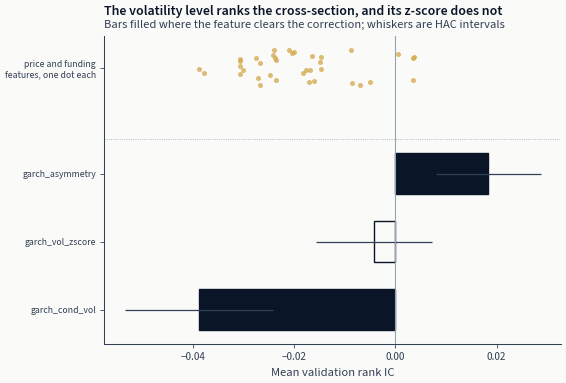

In [33]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    rows,
    plot_summary["mean_ic"].to_list(),
    height=0.6,
    edgecolor=COLORS["blue"],
    linewidth=1.0,
    color=bar_fill,
)
ax.errorbar(
    plot_summary["mean_ic"].to_list(),
    rows,
    xerr=interval,
    fmt="none",
    ecolor=COLORS["neutral"],
    elinewidth=0.9,
    capsize=2,
)
ax.scatter(financial_values, financial_jitter, s=9, color=COLORS["amber"], alpha=0.75)
ax.axvline(0, color=COLORS["recede"], linewidth=0.8)
ax.axhline(len(rows) - 0.5, color=COLORS["recede"], linewidth=0.6, linestyle=":")
ax.set_yticks(
    [*rows, REFERENCE_ROW],
    [*plot_summary["feature"].to_list(), "price and funding\nfeatures, one dot each"],
    fontsize=7,
)
ax.set(xlabel="Mean validation rank IC")
add_message_title(
    ax,
    "The volatility level ranks the cross-section, and its z-score does not",
    subtitle="Bars filled where the feature clears the correction; whiskers are HAC intervals",
)
fig.tight_layout()
show_with_alt(
    fig,
    "A horizontal bar chart of mean validation rank information coefficient for the "
    "model-based features, with HAC whiskers and bars filled only where the feature "
    "clears the false-discovery-rate correction, and above them a jittered row of dots "
    "on the same axis for each price and funding feature from the previous notebook. "
    "The conditional volatility bar reaches the negative edge of the dot cloud.",
)

The two regime probabilities are absent from the chart on the left, and that is a
property of the measure rather than of the features. A market-level quantity takes one
value across the whole cross-section at a settlement, so a rank correlation within the
settlement has nothing to rank. It does not follow that they carry no information: what
it means is that this particular screen cannot see it. Their use is as conditioning
variables, telling a nonlinear model that the same funding z-score should be read
differently in a stressed week. A cross-sectional rank correlation is the wrong
instrument for that, so their value has to be judged where a model can use them that
way rather than here.

**What the screen establishes, and what it does not.** Of the three features it can
rank, the conditional volatility level carries a clearly negative mean rank
information coefficient and is the only one that clears the multiplicity correction:
within a settlement, the more agitated perpetuals tend to be the weaker performers
over the next 8 hours. Its own trailing z-score and the fitted asymmetry coefficient
do not clear it, and the asymmetry is worth reading carefully - it is one number per
symbol per refit, so its information coefficient asks whether perpetuals with a stronger
leverage effect are persistently ranked. Under the previous design it moved twice across
the whole sample, once per fold, which left almost nothing for a rank correlation to
read; on the schedule it moves every `GARCH_REFIT_EVERY` settlements, so the measurement
below is against a feature that actually varies.

The dot row is what keeps this from being read as more than it is. The conditional
volatility bar sits at the negative edge of the existing features rather than beyond
it, and the dot next to it is `price_vol_14d`, printed above as the most negative of
the 37 - a trailing realized volatility computed with no model at all. On this
measure the fitted feature and the arithmetic one are hard to tell apart, which is a
reason to ask whether they carry the same information rather than an answer to it.
The two are built from the same returns and would be expected to correlate; whether
the GJR fit contributes anything the trailing window does not is a question about the
pair, and a chart of separate correlations cannot reach it. That is a useful answer
rather than a disappointing one: the case for the fitted feature has to rest on the
asymmetry and the conditioning it supplies to a nonlinear model, which a
stand-alone rank correlation cannot see, and the model notebooks are where it is
tested. Every magnitude here is small in absolute terms, which is the expected shape
for a volatility-state feature screened as a directional signal on its own.

## Key takeaways

- **Two channels, not one.** A fitted feature can look ahead through what it is
  *computed from* and through what its parameters were *estimated from*, and closing the
  first does nothing about the second. This notebook closed the first for a long time
  while leaving the second open, and every assertion it ran checked the channel that was
  already clean.
- **Filtered, not smoothed.** Any state-space model will happily report a state
  probability conditioned on the entire series, and that is the better estimate of
  history and an unusable feature. Ask what a live system could have computed at the
  decision, and emit that.
- **A schedule bounds an estimate; a fold selects rows.** Fitting per fold puts the
  validation window on the right side of the parameters and leaves the training window
  on the wrong side, because the recursion is then run forward from the start of the
  window the parameters were fitted on. Burn in, fit, emit, refit is the shape that makes
  the guarantee hold for every row rather than half of them.
- **The test is whether deleting the future moves the past.** Re-run the walk on a
  truncated series and every surviving value has to be unchanged. That is a check a
  fold-frozen fit fails, and it is the only one of these claims that cannot be satisfied
  by prose.
- **A burn-in is the honest answer where there is no history.** The first
  `MIN_TRAIN_BARS` settlements of a series carry no value because the feature did not
  exist yet. Producing a number there requires borrowing the future.
- **Correct the significance for the number of features screened.** Five features are
  five chances at a false positive, and a per-feature p-value read as if it were one
  is the cheapest way to promote noise.

**Known limitations of what is built here.**

- The refit cadence is a choice and not a derived quantity. `GARCH_REFIT_EVERY` and
  `HMM_REFIT_EVERY` were set to be frequent enough that a parameter is never badly stale
  and infrequent enough that the notebook finishes; refitting before every settlement is
  the limit these approximate, and how much the approximation costs is untested here.
- The estimation window expands rather than rolls, so an estimate late in the sample is
  influenced by settlements several years old. A rolling window would forget them. Which
  is right depends on whether the parameters are believed to be stable, and the stability
  panel in section D is the evidence for that question rather than an answer to it.
- The regime model reads funding alone. Price, volume and open interest carry regime
  information too, and a richer observation would very likely separate states the
  two-dimensional fit merges.
- Parameters are frozen from the holdout boundary onward, so a value dated late in the
  holdout is produced by an estimate that is by then as old as the holdout is long. That
  is the price of not estimating on the holdout, and it is the same price
  `cme_futures` pays for its ARIMA feature.
- The holdout fold's features exist and its geometry is in the sidecar, but a consumer that
  regenerates the fold set from `generate_cv_splits` instead of reading `fold_geometry` sees
  the validation folds only - so the holdout rows are in the parquet and invisible to it.
  `temporal_artifact_fold_boundaries` reads the sidecar first, which is what makes them
  reachable; anything hand-rolling the fold list will miss them.
- The screen at the end scores each feature on its own, so it says nothing about what
  these features contribute inside a model that also holds the other 39. Answering
  that needs a with-and-without comparison, and no stage of this pipeline runs one.

**Next**: [`05_evaluation`](05_evaluation.ipynb) screens the complete feature set
before any model is fitted in Chapters 11 to 15.